Simulando propagación en SOA...
BER = 6.105e-05 | Offset Óptimo: 16


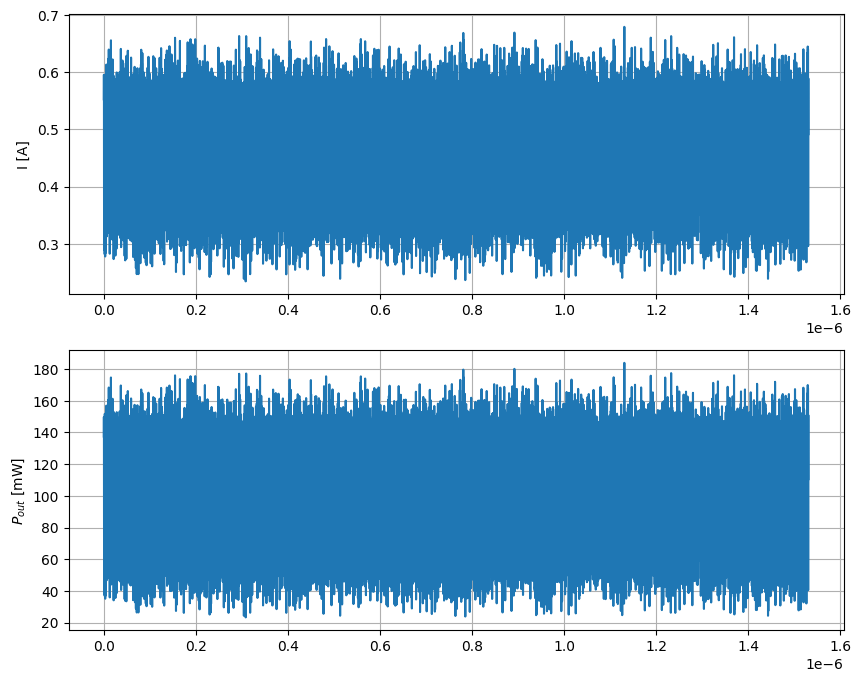

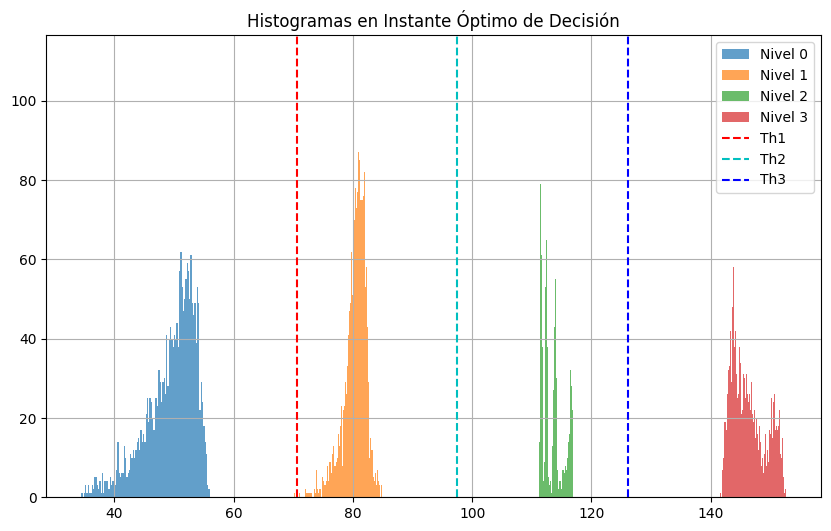

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import time
from params import SOAparams
from soa_main import run_simulation, plot_results, plot_eye_diagrams, plot_single_eye_with_hist

# Instanciar parámetros globales
p = SOAparams()
# I_trim es la corriente ideal (PAM-4)
# P_out_trim es la potencia óptica distorsionada
I_trim, P_out_trim, P_levels, thresholds, off_best = run_simulation()

# Gráficas de resultados e histogramas
plot_results(I_trim, P_out_trim, P_levels, thresholds, p.sample_period)

In [ ]:
import pandas as pd
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. CONFIGURACIÓN
WINDOW_SIZE = 32 

# 2. PREPARACIÓN DE DATOS (DataFrame corregido)
df = pd.DataFrame({
    'Time_s': np.arange(len(I_trim)) * p.sample_period,
    'Current_Input_A': I_trim,
    'Power_Output_mW': P_out_trim * 1e3  # Convertimos a mW si la red espera esa escala
})

def load_and_prep_data(df, window_size):
    X_raw = df['Power_Output_mW'].values.reshape(-1, 1)
    y_raw = df['Current_Input_A'].values.reshape(-1, 1)
    
    scaler_X = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))
    
    X_scaled = scaler_X.fit_transform(X_raw)
    y_scaled = scaler_y.fit_transform(y_raw)
    
    X_seq, y_seq = [], []
    offset = window_size // 2 
    for i in range(len(X_scaled) - window_size):
        X_seq.append(X_scaled[i : i + window_size])
        y_seq.append(y_scaled[i + offset])
        
    return np.array(X_seq), np.array(y_seq), scaler_X, scaler_y

# 3. PROCESAMIENTO
X, y, scaler_X, scaler_y = load_and_prep_data(df, WINDOW_SIZE)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 4. MODELO
model = Sequential([
    Input(shape=(WINDOW_SIZE, 1)), 
    Bidirectional(LSTM(units=50, return_sequences=False)),
    Dense(32, activation='relu'),
    Dense(1, activation='linear') 
])
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# 5. ENTRENAMIENTO
print("Entrenando BiLSTM...")
history = model.fit(
    X_train, y_train,
    epochs=15, 
    batch_size=256, 
    validation_split=0.1,
    verbose=1
)

# 6. INFERENCIA CON ALINEACIÓN
y_pred_scaled = model.predict(X_test)
y_pred_unaligned = scaler_y.inverse_transform(y_pred_scaled)
y_true_unaligned = scaler_y.inverse_transform(y_test)

# CORRECCIÓN DE DESFASE
# Calcular la posición absoluta donde empieza el set de prueba en el DF original
# (Considerar el recorte inicial que hace la función load_and_prep_data)
test_start_index = len(X_train) + (WINDOW_SIZE // 2)

# Calcular la diferencia para llegar al siguiente inicio de bit (p.samples_per_bit)
shift = (p.samples_per_bit - (test_start_index % p.samples_per_bit)) % p.samples_per_bit

# Recortar ambos arrays para su sincronización
y_pred = y_pred_unaligned[shift:]
y_true = y_true_unaligned[shift:]

Entrenando BiLSTM...
Epoch 1/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - loss: 0.0021 - val_loss: 4.2950e-05
Epoch 2/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - loss: 3.6045e-05 - val_loss: 2.6014e-05
Epoch 3/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - loss: 2.6427e-05 - val_loss: 2.2487e-05
Epoch 4/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - loss: 2.0831e-05 - val_loss: 1.3860e-05
Epoch 5/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step - loss: 1.8430e-05 - val_loss: 2.5340e-05
Epoch 6/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 31s 42ms/step - loss: 1.5586e-05 - val_loss: 1.9517e-05
Epoch 7/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - loss: 1.4778e-05 - val_loss: 1.0099e-05
Epoch 8/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - loss: 1.4037e-05 - val_loss: 3.5188e-05
Epoch 9/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - loss: 1.2593e-05 - val_loss: 3.2167e-05
Epoch 10/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - loss: 1.2456e-05 - val_loss: 9.6205e-06
Epoch 11/15
737/737 ━━

c:\SOA\SOA_UNAM_16\soa_main.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  span_ui = 4; samples_span = span_ui * UI


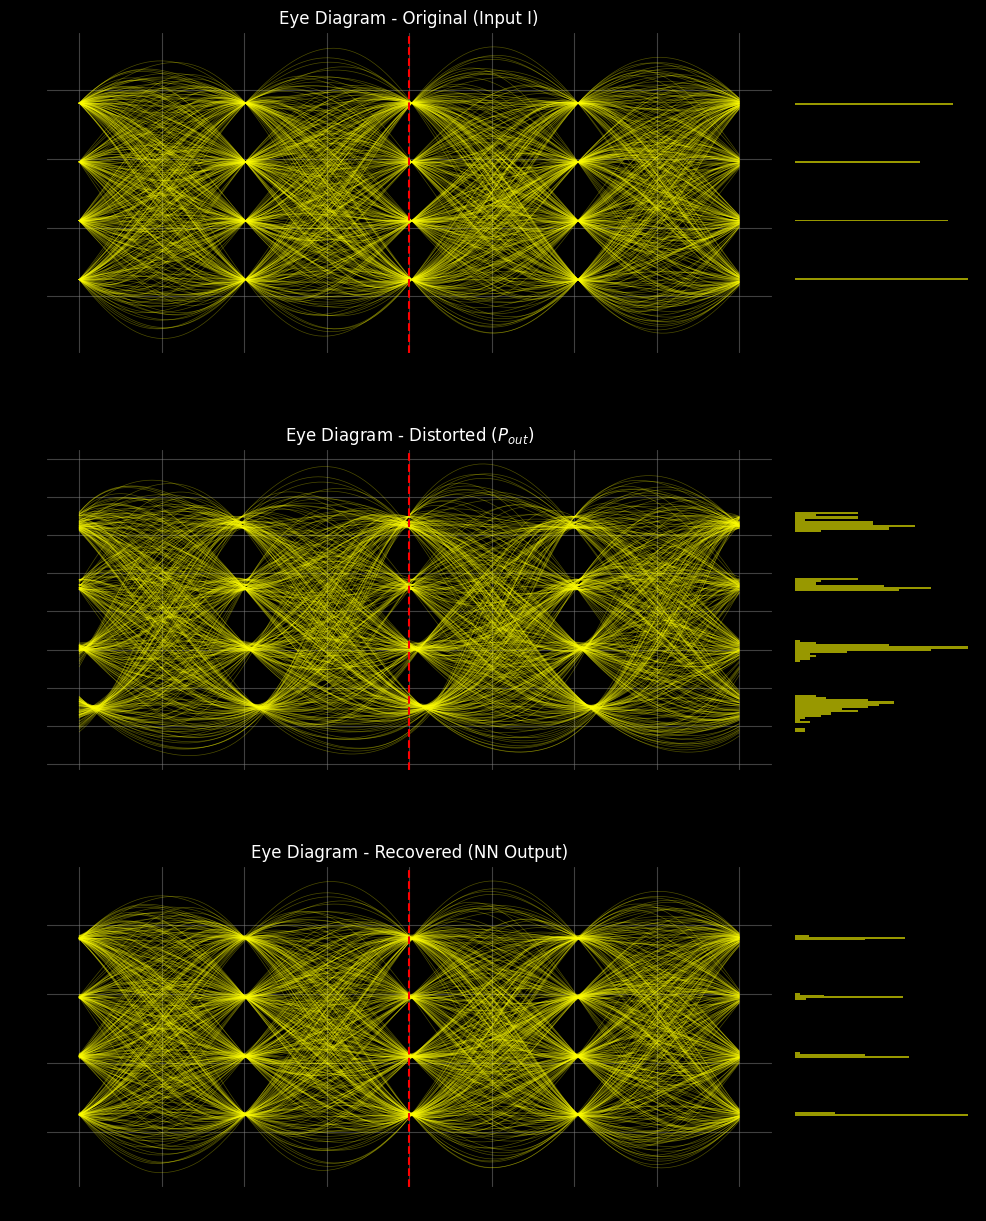

In [ ]:
# Definir la señal distorsionada 
start_idx = test_start_index + shift
end_idx = start_idx + len(y_true)
P_test_segment = P_out_trim[start_idx : end_idx]

# Preparar la lista de señales para la función
signals_to_plot = [
    (y_true.flatten(), 'Original (Input I)', 1.0),
    (P_test_segment.flatten(), 'Distorted ($P_{out}$)', 1e3),
    (y_pred.flatten(), 'Recovered (NN Output)', 1.0)
]
plot_eye_diagrams(signals_to_plot, p.samples_per_bit, off_best)